# Ch06_07 — Policy Gradient: REINFORCE (akcje ciągłe)

W bloku 1 (MC/TD) pracowaliśmy z **tablicami**: \(V(s)\), \(Q(s,a)\).  
W środowiskach z **akcjami ciągłymi** (np. MuJoCo) nie da się łatwo zrobić \(\arg\max_a Q(s,a)\), więc naturalnie przechodzimy do **policy-based**:

$
\pi_\theta(a\mid s)\quad \text{(polityka z parametrami \(\theta\))}
$

## Co optymalizujemy?

Chcemy maksymalizować oczekiwany zdyskontowany zwrot:

$
J(\theta)=\mathbb{E}_{\tau\sim \pi_\theta}\left[\sum_{t=0}^{T-1}\gamma^t r_{t+1}\right]
$

**Policy Gradient Theorem** mówi, że gradient da się estymować z próbek:

$
\nabla_\theta J(\theta)\;\approx\; \sum_{t}\nabla_\theta \log \pi_\theta(a_t\mid s_t)\; \hat A_t
$

gdzie \(\hat A_t\) to „sygnał uczenia” (np. zwrot \(G_t\) lub advantage z baseline).

---

## REINFORCE (episodic) — idea

W REINFORCE zbieramy cały epizod, liczymy zwroty $G_t$ i robimy update:

$
\theta \leftarrow \theta + \alpha \sum_t \nabla_\theta \log \pi_\theta(a_t\mid s_t)\; (G_t - b_t)
$

- $b_t$ to **baseline** (np. $V(s_t)$), który **nie zmienia wartości oczekiwanego gradientu**, ale zmniejsza wariancję.
- Bez baseline REINFORCE działa, ale zwykle jest „szumiący” i wolniejszy.

### Pseudokod (REINFORCE + baseline)

1. Zainicjalizuj politykę $\pi_\theta$ i baseline $V_\phi$  
2. Dla każdego epizodu:
   - Zbierz trajektorię $(s_t,a_t,r_{t+1})$
   - Policz zwroty $G_t$
   - Advantage: $\hat A_t = G_t - V_\phi(s_t)$
   - Update aktora: minimalizuj $-\log\pi_\theta(a_t|s_t)\hat A_t$
   - Update krytyka: minimalizuj $\big(V_\phi(s_t)-G_t\big)^2$

---

## W tym notebooku

- Środowisko: **Pendulum-v1** (ciągłe akcje, szybkie na CPU)
- Polityka: Gauss + **tanh-squash** (żeby akcje były w zakresie $[low, high]$)
- Porównanie: baseline vs brak baseline (opcjonalnie)

> Jeśli chcesz MuJoCo: w PPO notebooku przełączymy na InvertedPendulum/Hopper/Walker2d/HalfCheetah.


In [1]:
# Jeśli nie masz gymnasium:
# !pip install gymnasium
# Dla MuJoCo (opcjonalnie):
# !pip install "gymnasium[mujoco]"

import numpy as np
import matplotlib.pyplot as plt

import torch

# lokalny import (plik obok notebooka)
from policy_based_continuous import train_reinforce


## Konfiguracja eksperymentu

Kilka uwag:
- REINFORCE jest **on-policy** i zbiera pełne epizody.
- Dla Pendulum epizod ma domyślnie ~200 kroków, więc 300–800 epizodów zwykle wystarczy na sensowny trend.
- Uwaga na interpretację reward: w Pendulum nagrody są ujemne, więc „lepiej” = mniej ujemnie.


In [2]:
cfg = dict(
    env_id="Pendulum-v1",
    seed=0,
    total_episodes=500,
    gamma=0.99,
    actor_lr=3e-4,
    critic_lr=1e-3,
    baseline=True,          # zmień na False żeby zobaczyć wariancję bez baseline
    hidden_sizes=(64, 64),
)

ac, log = train_reinforce(**cfg)
log.steps[:5], log.avg_return[:5], len(log.steps)


/home/piotr/anaconda3/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


([2000, 4000, 6000, 8000, 10000],
 [-1269.9896175487793,
  -1210.2303214330307,
  -1229.0758147824333,
  -1273.1576524991692,
  -1371.351540767939],
 50)

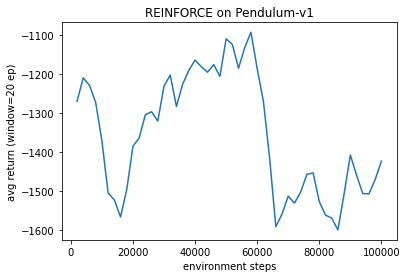

In [3]:
plt.figure()
plt.plot(log.steps, log.avg_return)
plt.xlabel("environment steps")
plt.ylabel("avg return (window=20 ep)")
plt.title("REINFORCE on Pendulum-v1")
plt.show()


## Co dalej?

REINFORCE działa, ale:
- jest **mało sample-efficient** (czeka na cały epizod),
- ma sporą **wariancję** gradientu.

W następnym notebooku przechodzimy do **Actor-Critic (A2C)**:
- krytyk daje baseline *i* bootstrapping (TD),
- update jest „częściej” i zwykle stabilniej.
